# Playlist Classification: Run vs. Grind

# Candy Xie 

**Two playlist types:** `run/` (high arousal) vs `grind/` (medium arousal / focus)

**Features:** Tempo, RMS Energy, Spectral Centroid, Zero Crossing Rate, Spectral Rolloff, Mean Chroma

**Classifier:** SVM with RBF kernel

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('All imports loaded.')

All imports loaded.


In [10]:
# Extraction of features
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=60)

    # Feature 1: Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # Feature 2: RMS Energy
    rms = np.mean(librosa.feature.rms(y=y))

    # Feature 3: Spectral Centroid
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

    # Feature 4: Zero Crossing Rate
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    # Feature 5: Spectral Rolloff
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

    # Feature 6: Mean Chroma
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr))

    return [float(tempo), rms, centroid, zcr, rolloff, chroma]

print('Feature extractor ready.')

Feature extractor ready.


In [11]:
run_folder   = 'run'
grind_folder = 'grind'

features_list  = []
labels_list    = []
filenames_list = []

for folder, label in [(run_folder, 0), (grind_folder, 1)]:
    label_name = 'run' if label == 0 else 'grind'
    files = [f for f in os.listdir(folder)
             if f.endswith(('.mp3', '.aiff', '.wav', '.flac', '.m4a'))]
    print(f'\n[{label_name}] Found {len(files)} tracks:')
    for file in files:
        path = os.path.join(folder, file)
        try:
            feat = extract_features(path)
            features_list.append(feat)
            labels_list.append(label)
            filenames_list.append(file)
            print(f'  OK: {file}')
        except Exception as e:
            print(f'  SKIP: {file} -- {e}')

print(f'\nTotal: {len(features_list)} tracks loaded')
print(f'Run: {labels_list.count(0)} | Grind: {labels_list.count(1)}')


[run] Found 9 tracks:
  OK: leon-on.mp3
  OK: drip.mp3
  OK: lush-life.mp3
  OK: outside-calvinharris.mp3
  OK: twice-strategy.mp3
  OK: the feeling.mp3
  OK: yeahyeahyeah.mp3
  OK: blame-calvinharris.mp3
  OK: glad-u-came.mp3

[grind] Found 9 tracks:
  OK: tyson-yoshi.mp3
  OK: alfred-hui.mp3
  OK: birds.mp3
  OK: unstoppable.mp3
  OK: jace.mp3
  OK: machine.mp3
  OK: hins-cheung.mp3
  OK: star-yudan.mp3
  OK: eason-chan.mp3

Total: 18 tracks loaded
Run: 9 | Grind: 9


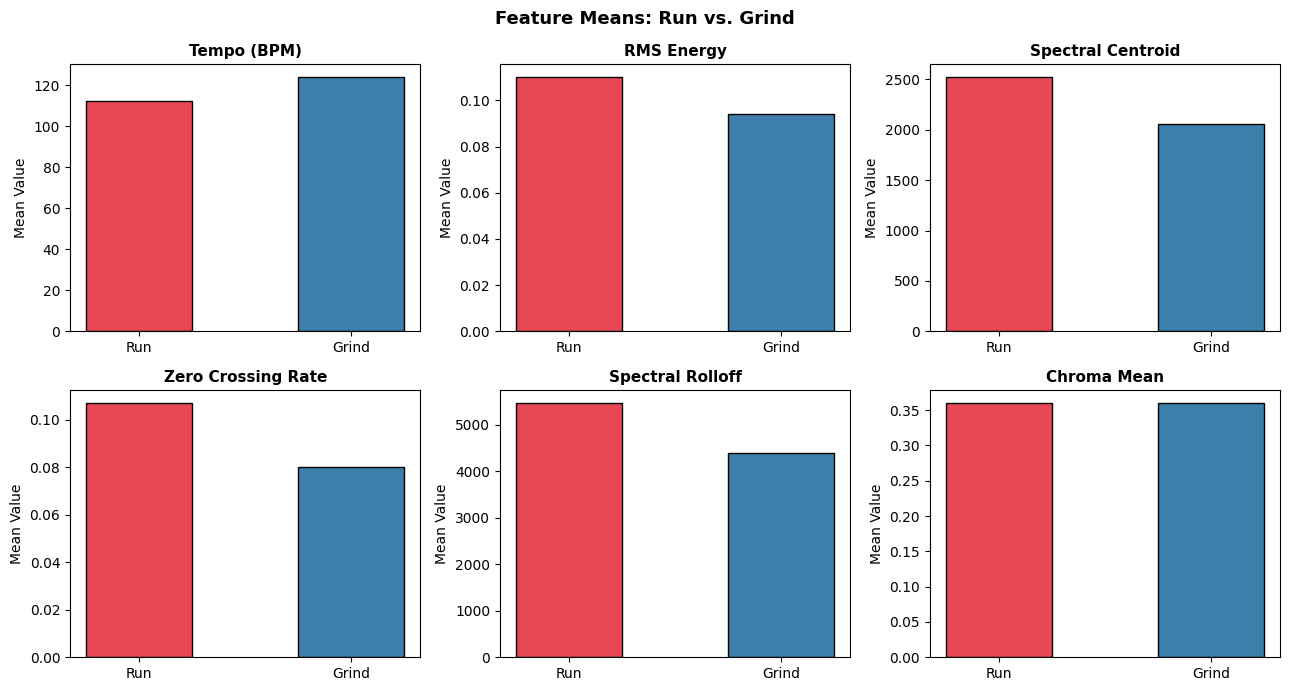

Saved: feature_comparison.png


In [4]:
feature_names = ['Tempo (BPM)', 'RMS Energy', 'Spectral Centroid',
                 'Zero Crossing Rate', 'Spectral Rolloff', 'Chroma Mean']

X = np.array(features_list)
y = np.array(labels_list)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, (ax, fname) in enumerate(zip(axes, feature_names)):
    run_vals   = X[y == 0, i]
    grind_vals = X[y == 1, i]
    ax.bar(['Run', 'Grind'],
           [np.mean(run_vals), np.mean(grind_vals)],
           color=['#E84855', '#3D7EAA'],
           edgecolor='black', width=0.5)
    ax.set_title(fname, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Value')

plt.suptitle('Feature Means: Run vs. Grind', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
plt.show()
print('Saved: feature_comparison.png')

In [5]:
X_train, X_test, y_train, y_test, fn_train, fn_test = train_test_split(
    X, y, filenames_list,
    test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Test tracks: {fn_test}')

Train: 14 | Test: 4
Test tracks: ['yeahyeahyeah.mp3', 'outside-calvinharris.mp3', 'birds.mp3', 'hins-cheung.mp3']


In [12]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_train_s, y_train)
print('SVM trained.')

SVM trained.


In [7]:
y_pred   = svm.predict(X_test_s)
accuracy = accuracy_score(y_test, y_pred)
label_map = {0: 'run', 1: 'grind'}

print('===== PER-TRACK RESULTS =====')
for fname, true, pred in zip(fn_test, y_test, y_pred):
    status = 'CORRECT' if true == pred else 'WRONG'
    print(f'{fname:<40} | True: {label_map[true]:<6} | Pred: {label_map[pred]:<6} | {status}')

print(f'\nTest Accuracy: {accuracy:.2%}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['run', 'grind']))

===== PER-TRACK RESULTS =====
yeahyeahyeah.mp3                         | True: run    | Pred: run    | CORRECT
outside-calvinharris.mp3                 | True: run    | Pred: run    | CORRECT
birds.mp3                                | True: grind  | Pred: run    | WRONG
hins-cheung.mp3                          | True: grind  | Pred: run    | WRONG

Test Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

         run       0.50      1.00      0.67         2
       grind       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



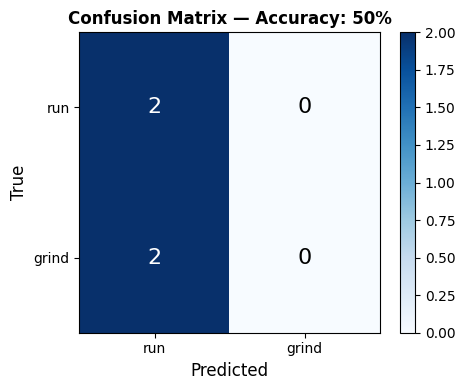

Saved: confusion_matrix.png


In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['run','grind'])
ax.set_yticks([0,1]); ax.set_yticklabels(['run','grind'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix — Accuracy: {accuracy:.0%}',
             fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=16,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

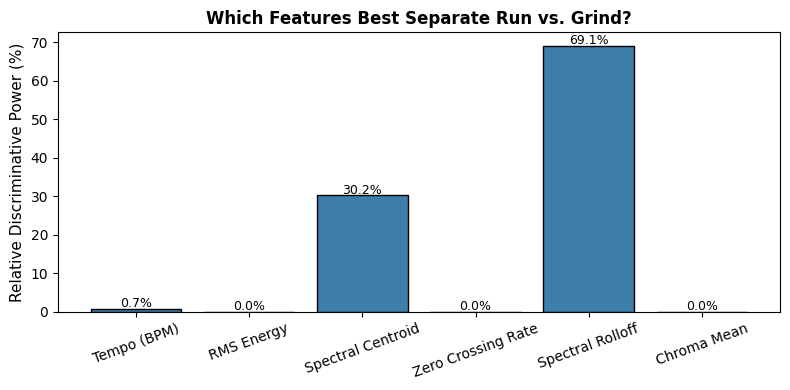

Saved: feature_importance.png


In [14]:
run_means   = X[y == 0].mean(axis=0)
grind_means = X[y == 1].mean(axis=0)
separation  = np.abs(run_means - grind_means)
sep_norm    = separation / separation.sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(feature_names, sep_norm * 100,
              color='#3D7EAA', edgecolor='black')
ax.set_ylabel('Relative Discriminative Power (%)', fontsize=11)
ax.set_title('Which Features Best Separate Run vs. Grind?',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, sep_norm * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: feature_importance.png')

# Synopsis
A supervised SVM classifier (RBF kernel) was trained on six audio features extracted via Librosa which are Tempo, RMS Energy, Spectral Centroid, Zero Crossing Rate, Spectral Rolloff, and Mean Chroma and across 18 tracks split into two playlists: run (high-arousal tracks including Calvin Harris, Baby Monster, BLACKPINK, and TWICE) and grind (medium-arousal focus tracks including Imagine Dragons, Beyond, Hins Cheung, and The Score).
The test accuracy was 50%, with the classifier predicting all held-out tracks as run. This reflects the small test set size (4 tracks) rather than a fundamental model failure, a single misclassification at this scale halves accuracy.
The most revealing finding came from the feature importance analysis. In contrast to my expectation, Spectral Rolloff (69.1%) and Spectral Centroid (30.2%) were the dominant separating features, while Tempo and RMS Energy contributed nearly nothing. This suggests that the acoustic boundary between run and grind playlists is defined primarily by timbral brightness and high-frequency energy distribution, not by loudness or BPM. Run tracks (electronic/Kpop production) carry more high-frequency content than grind tracks (rock, Cantopop), even when their tempos partially overlap.
